# Order Parameters

To characterize the orientational organization of elongated cells, the following global order parameters are recorded.

The global nematic order is defined as

\begin{equation}
    Q_{E, elongated}(t)
    =
    \frac{1}{N_e(t)}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(2\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(2\varphi_i(t)\right)
        \right]^2
    }.
\end{equation}

The global polar order is defined as

\begin{equation}
    P_{E, elongated}(t)
    =
    \frac{1}{N_e(t)}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(\varphi_i(t)\right)
        \right]^2
    }.
\end{equation}

We also calculate the parameters normalized by the total number of cells:

\begin{equation}
    Q_{E, total}(t)
    =
    \frac{1}{N}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(2\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(2\varphi_i(t)\right)
        \right]^2
    },
\end{equation}

and 

\begin{equation}
    P_{E, total}(t)
    =
    \frac{1}{N}
    \sqrt{
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \sin\left(\varphi_i(t)\right)
        \right]^2
        +
        \left[
            \sum_{i\in\mathcal{E}(t)}
            \cos\left(\varphi_i(t)\right)
        \right]^2
    }.
\end{equation}

The phenotypic composition is characterized by

\begin{equation}
    f_E(t)
    =
    \frac{N_e(t)}{N}.
\end{equation}

These quantities satisfy

\begin{equation}
    P_{E, total}(t)=f_E(t)P_{E, elongated}(t),
    \qquad
    Q_{E, total}(t)=f_E(t)Q_{E, elongated}(t).
\end{equation}

When $N_e(t)=0$, the order parameters normalized by the elongated population are set to zero.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load and inspect data

We start by loading and inspecting the processed order-parameter data.

In [2]:
# Load order parameters data
DATA_DIR = "data/order_parameters"

order_parameters = pd.read_parquet(
    f"{DATA_DIR}/order_parameters.parquet"
)

# Display the first few rows of the order parameters DataFrame
order_parameters.head()

,N,reference_N,actual_N,rho,actual_rho,seed,step,initial_fraction_elongated,force,nematic,polar,nematic_2,polar_2,fraction_elongated
0,5000,5016,4437,0.8,0.800003,7713914261614,0,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.000000,0.000000,0.000000,0.000000,0.000000
1,5000,5016,4437,0.8,0.800003,7713914261614,100,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.312978,0.131144,0.001270,0.000532,0.004057
2,5000,5016,4437,0.8,0.800003,7713914261614,200,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.132258,0.062419,0.000864,0.000408,0.006536
3,5000,5016,4437,0.8,0.800003,7713914261614,300,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.073004,0.077315,0.000675,0.000714,0.009240
4,5000,5016,4437,0.8,0.800003,7713914261614,400,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.192110,0.059491,0.002555,0.000791,0.013297


In [3]:
# Print the shape of the DataFrame
print("Shape:", order_parameters.shape)

# Print the column names and their data types
print("\nColumns:")
print(order_parameters.columns.tolist())

print("\nDtypes:")
print(order_parameters.dtypes)

Shape: (485273, 14)

Columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'nematic', 'polar', 'nematic_2', 'polar_2', 'fraction_elongated']

Dtypes:
N                               int64
reference_N                     int64
actual_N                        int64
rho                           float64
actual_rho                    float64
seed                            int64
step                            int64
initial_fraction_elongated    float64
force                             str
nematic                       float64
polar                         float64
nematic_2                     float64
polar_2                       float64
fraction_elongated            float64
dtype: object


In [4]:
# Print the unique values of the "N" column
print("N values:")
print(sorted(order_parameters["N"].unique()))

# Print the unique values of the "rho" column
print("\nNumber of seeds by N and rho:")
display(
    order_parameters
    .groupby(["N", "rho"])["seed"]
    .nunique()
    .to_frame("n_seeds")
)

N values:
[np.int64(5000), np.int64(10000)]

Number of seeds by N and rho:


n_seeds
N     rho           
5000  0.800       64
      0.810       64
      0.820       64
      0.830       64
      0.840       64
      0.850       64
      0.860       64
      0.870       64
10000 0.800       32
      0.810       32
      0.820       32
      0.830       32
      0.840       32
      0.850       32
      0.855       32
      0.860       32
      0.865       32
      0.870       32

In [5]:
# Verify the range of steps in the order parameters DataFrame
print("Step range:")
print(
    "min =", order_parameters["step"].min(),
    "max =", order_parameters["step"].max(),
)

print(
    "number of unique steps =",
    order_parameters["step"].nunique(),
)

print("\nFirst steps:")
print(
    sorted(order_parameters["step"].unique())[:20]
)

Step range:
min = 0 max = 80000
number of unique steps = 801

First steps:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]


In [6]:
# Summarize the coverage of steps for each combination of rho and seed
coverage = (
    order_parameters
    .groupby(["N", "rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
)

display(
    coverage
    .groupby(["N", "rho"])
    .agg(["min", "max"])
)

min        max        nunique     
            min max    min    max     min  max
N     rho                                     
5000  0.800   0   0  44200  50100     443  502
      0.810   0   0  43900  50000     440  501
      0.820   0   0  43000  47300     431  474
      0.830   0   0  42100  48300     422  484
      0.840   0   0  41300  79700     414  798
      0.850   0   0  41100  75900     412  760
      0.860   0   0  40500  68900     406  690
      0.870   0   0  40500  62000     406  621
10000 0.800   0   0  80000  80000     801  801
      0.810   0   0  80000  80000     801  801
      0.820   0   0  80000  80000     801  801
      0.830   0   0  80000  80000     801  801
      0.840   0   0  80000  80000     801  801
      0.850   0   0  80000  80000     801  801
      0.855   0   0  20100  32100     202  322
      0.860   0   0  80000  80000     801  801
      0.865   0   0  20100  29200     202  293
      0.870   0   0  80000  80000     801  801

In [7]:
# Check for duplicates in the order parameters DataFrame
n_duplicates = order_parameters.duplicated(
    ["N", "rho", "seed", "step"]
).sum()

print("Duplicated (N, rho, seed, step):", n_duplicates)

Duplicated (N, rho, seed, step): 0


In [8]:
# Check for missing values in the order parameters DataFrame
display(
    order_parameters.isna().sum().to_frame("n_nan")
)

,n_nan
N,0
reference_N,0
actual_N,0
rho,0
actual_rho,0
seed,0
step,0
initial_fraction_elongated,0
force,0
nematic,0


In [9]:
# Verify the identities polar_2 = f_E * polar and nematic_2 = f_E * nematic
polar_identity = np.allclose(
    order_parameters["polar_2"],
    order_parameters["fraction_elongated"]
    * order_parameters["polar"],
    equal_nan=True,
)

nematic_identity = np.allclose(
    order_parameters["nematic_2"],
    order_parameters["fraction_elongated"]
    * order_parameters["nematic"],
    equal_nan=True,
)

print("polar_2 = f_E * polar:", polar_identity)
print("nematic_2 = f_E * nematic:", nematic_identity)

polar_2 = f_E * polar: True
nematic_2 = f_E * nematic: True


In [10]:
# Create a copy of the order_parameters DataFrame and rename columns for clarity
op = order_parameters.copy()

op["f_E"] = op["fraction_elongated"]

op["P_E_elongated"] = op["polar"]
op["Q_E_elongated"] = op["nematic"]

op["P_E_total"] = op["polar_2"]
op["Q_E_total"] = op["nematic_2"]

## Time evolution of order parameters

Now that we have inspected the data, we can start analyzing the evolution of the order parameters.

In [11]:
# Average over seeds at each time
# We group by density and step, and compute the mean and standard deviation
# of the morphology and order parameters across seeds.

# Select the system size used for the detailed time evolution
N_time = 10_000

op_time_selected = op[
    op["N"] == N_time
].copy()

# Average over seeds at each time
op_time = (
    op_time_selected
    .groupby(["rho", "step"])
    .agg(
        f_E_mean=("f_E", "mean"),
        f_E_std=("f_E", "std"),

        P_E_elongated_mean=("P_E_elongated", "mean"),
        P_E_elongated_std=("P_E_elongated", "std"),

        Q_E_elongated_mean=("Q_E_elongated", "mean"),
        Q_E_elongated_std=("Q_E_elongated", "std"),

        P_E_total_mean=("P_E_total", "mean"),
        P_E_total_std=("P_E_total", "std"),

        Q_E_total_mean=("Q_E_total", "mean"),
        Q_E_total_std=("Q_E_total", "std"),
    )
    .reset_index()
)

op_time.head()

,rho,step,f_E_mean,f_E_std,P_E_elongated_mean,P_E_elongated_std,Q_E_elongated_mean,Q_E_elongated_std,P_E_total_mean,P_E_total_std,Q_E_total_mean,Q_E_total_std
0,0.8,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.8,100,0.003663,0.000838,0.140318,0.071728,0.151277,0.085216,0.000488,0.000208,0.000528,0.000274
2,0.8,200,0.005865,0.001141,0.139416,0.094908,0.100676,0.064075,0.000785,0.000500,0.000582,0.000377
3,0.8,300,0.008431,0.001707,0.115062,0.068422,0.115743,0.047180,0.000946,0.000580,0.000955,0.000423
4,0.8,400,0.011962,0.002575,0.103845,0.055198,0.093661,0.052614,0.001197,0.000605,0.001053,0.000485


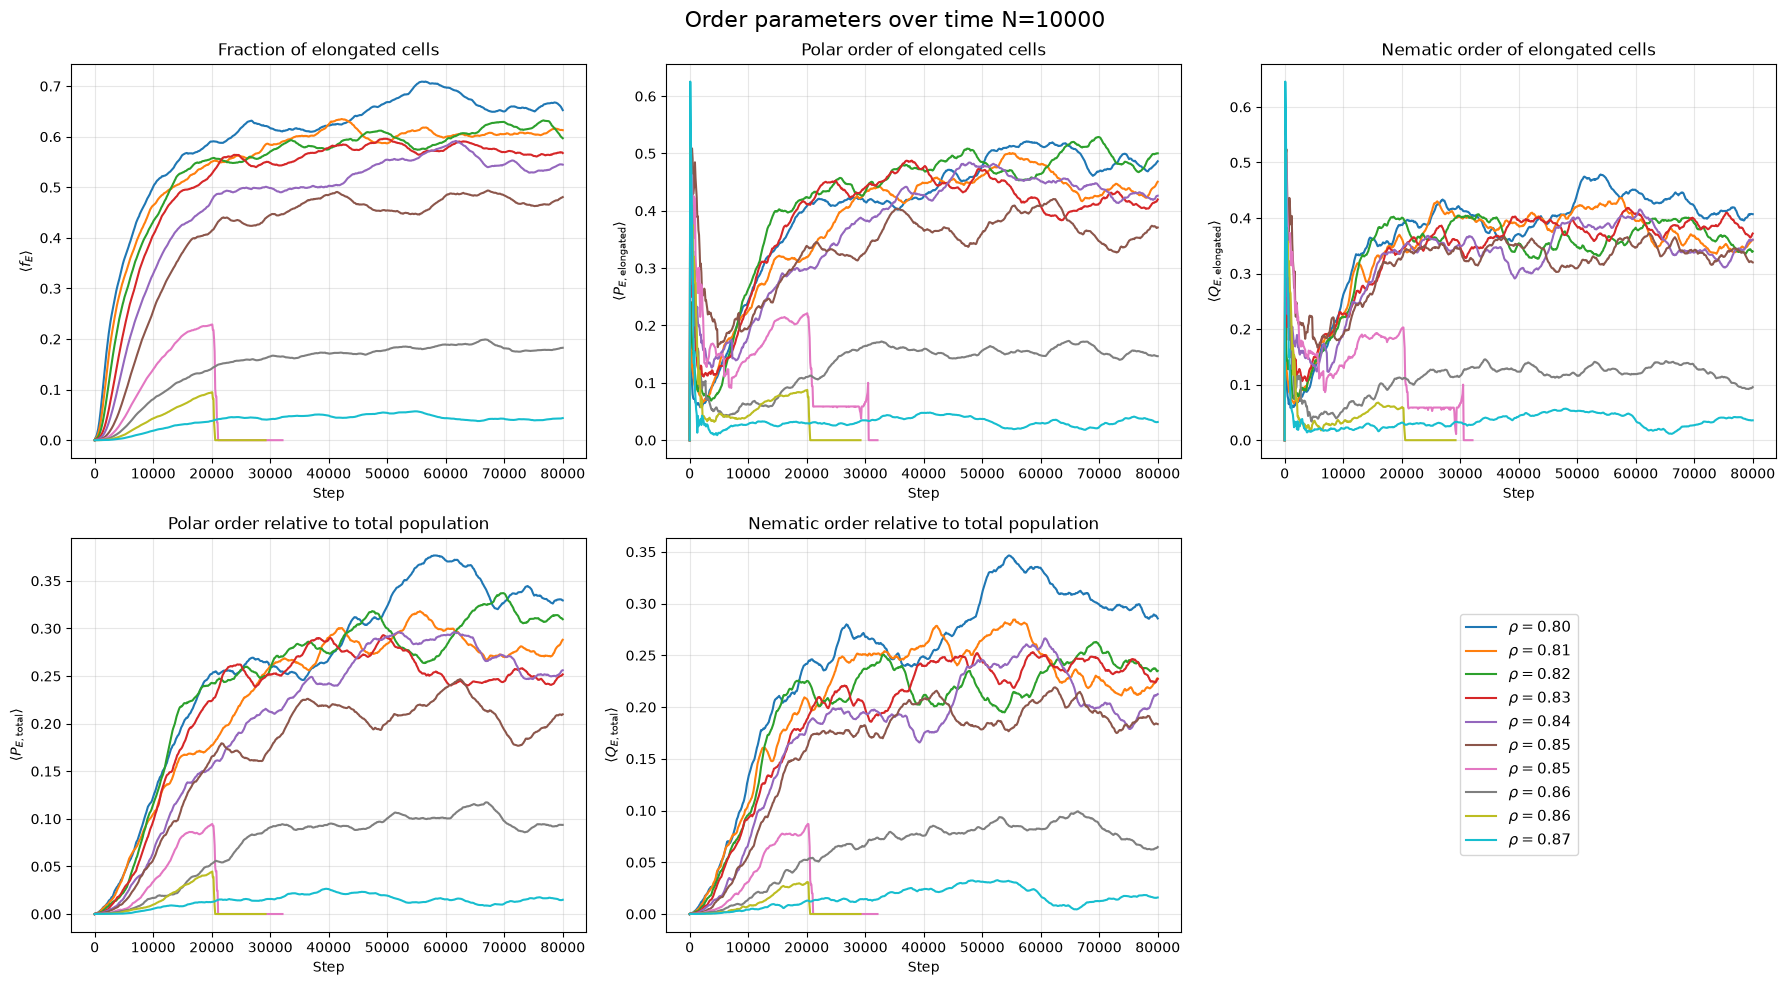

In [12]:
# Plot the order parameters over time for different densities
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Define the observables to plot, along with their labels and titles
observables = [
    ("f_E_mean", r"$\langle f_E \rangle$", "Fraction of elongated cells"),
    (
        "P_E_elongated_mean",
        r"$\langle P_{E,\mathrm{elongated}} \rangle$",
        "Polar order of elongated cells",
    ),
    (
        "Q_E_elongated_mean",
        r"$\langle Q_{E,\mathrm{elongated}} \rangle$",
        "Nematic order of elongated cells",
    ),
    (
        "P_E_total_mean",
        r"$\langle P_{E,\mathrm{total}} \rangle$",
        "Polar order relative to total population",
    ),
    (
        "Q_E_total_mean",
        r"$\langle Q_{E,\mathrm{total}} \rangle$",
        "Nematic order relative to total population",
    ),
]

axs = axs.flatten()

# For each observable, plot the mean value over time for each density (rho)
for ax, (column, ylabel, title) in zip(axs, observables):

    for rho, df_rho in op_time.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho[column],
            label=fr"$\rho={rho:.2f}$"
        )

    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)

    # ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.grid(alpha=0.3)

# The sixth panel is not used
axs[-1].axis("off")

# Put the legend in the empty panel
handles, labels = axs[0].get_legend_handles_labels()

axs[-1].legend(
    handles,
    labels,
    loc="center",
    fontsize=11,
)

# Plot configuration
graph_title = f"Order parameters over time N={N_time}"
fig.suptitle(graph_title, fontsize=16)
rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()
plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

$f_E$ increases progressively from the initially round configuration. For lower densities, a substantial fraction of the population becomes elongated, while the elongated fraction is strongly suppressed at the highest densities. 

$P_{E, total}$ and $Q_{E, total}$ show the same suppression at high density, indicating that collective orientational order becomes macroscopically small when elongation is inhibited.

$P_{E, elongated}$ and $Q_{E, elongated}$ remain finite whenever an elongated subpopulation is present. At very early times, these quantities should be interpreted with caution because $N_E$ is still very small.

## Steady state

To obtain a more stable estimate of the order parameters and compare their dependence on density, we average each observable over the final $10\%$ of each realization. We first perform the temporal average independently for each seed and then average over realizations.

At this stage, the final $10\%$ is used as a late-time averaging window rather than assuming that all realizations have reached a fully stationary state. Longer simulations will be used to assess convergence.

In [13]:
# Fraction of each realization used as late-time window
steady_fraction = 0.10

# Maximum simulated step for each realization
max_step_per_seed = (
    op
    .groupby(["N", "rho", "seed"])["step"]
    .transform("max")
)

# Keep the final 10% of each realization independently
op_steady = op[
    op["step"] >= max_step_per_seed * (1 - steady_fraction)
].copy()

In [14]:
late_time_coverage = (
    op_steady
    .groupby(["N", "rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
)

display(
    late_time_coverage
    .groupby(["N", "rho"])
    .agg(["min", "max"])
)

min           max        nunique    
               min    max    min    max     min max
N     rho                                          
5000  0.800  39800  45100  44200  50100      45  51
      0.810  39600  45000  43900  50000      44  51
      0.820  38700  42600  43000  47300      44  48
      0.830  37900  43500  42100  48300      43  49
      0.840  37200  71800  41300  79700      42  80
      0.850  37000  68400  41100  75900      42  76
      0.860  36500  62100  40500  68900      41  69
      0.870  36500  55800  40500  62000      41  63
10000 0.800  72000  72000  80000  80000      81  81
      0.810  72000  72000  80000  80000      81  81
      0.820  72000  72000  80000  80000      81  81
      0.830  72000  72000  80000  80000      81  81
      0.840  72000  72000  80000  80000      81  81
      0.850  72000  72000  80000  80000      81  81
      0.855  18100  28900  20100  32100      21  33
      0.860  72000  72000  80000  80000      81  81
      0.865  18100  26300  20100  29200      21  30
      0.870  72000  72000  80000  80000      81  81

In [15]:
# First average over time for each seed
op_seed_stats = (
    op_steady
    .groupby(["N", "rho", "seed"])
    .agg(
        f_E=("f_E", "mean"),
        P_E_elongated=("P_E_elongated", "mean"),
        Q_E_elongated=("Q_E_elongated", "mean"),
        P_E_total=("P_E_total", "mean"),
        Q_E_total=("Q_E_total", "mean"),
    )
    .reset_index()
)

op_seed_stats.head()

,N,rho,seed,f_E,P_E_elongated,Q_E_elongated,P_E_total,Q_E_total
0,5000,0.8,7713914261614,0.998078,0.295385,0.902757,0.294817,0.901024
1,5000,0.8,12944511869278,0.808111,0.656957,0.342663,0.530328,0.277583
2,5000,0.8,37852570490343,0.987595,0.860229,0.779170,0.849570,0.769510
3,5000,0.8,78804909138230,0.997192,0.932248,0.921796,0.929644,0.919225
4,5000,0.8,121838283310165,0.626672,0.569806,0.332147,0.357379,0.210241


In [16]:
# Then average over seeds
op_rho_stats = (
    op_seed_stats
    .groupby(["N", "rho"])
    .agg(
        f_E_mean=("f_E", "mean"),
        f_E_std=("f_E", "std"),

        P_E_elongated_mean=("P_E_elongated", "mean"),
        P_E_elongated_std=("P_E_elongated", "std"),

        Q_E_elongated_mean=("Q_E_elongated", "mean"),
        Q_E_elongated_std=("Q_E_elongated", "std"),

        P_E_total_mean=("P_E_total", "mean"),
        P_E_total_std=("P_E_total", "std"),

        Q_E_total_mean=("Q_E_total", "mean"),
        Q_E_total_std=("Q_E_total", "std"),
    )
    .reset_index()
)

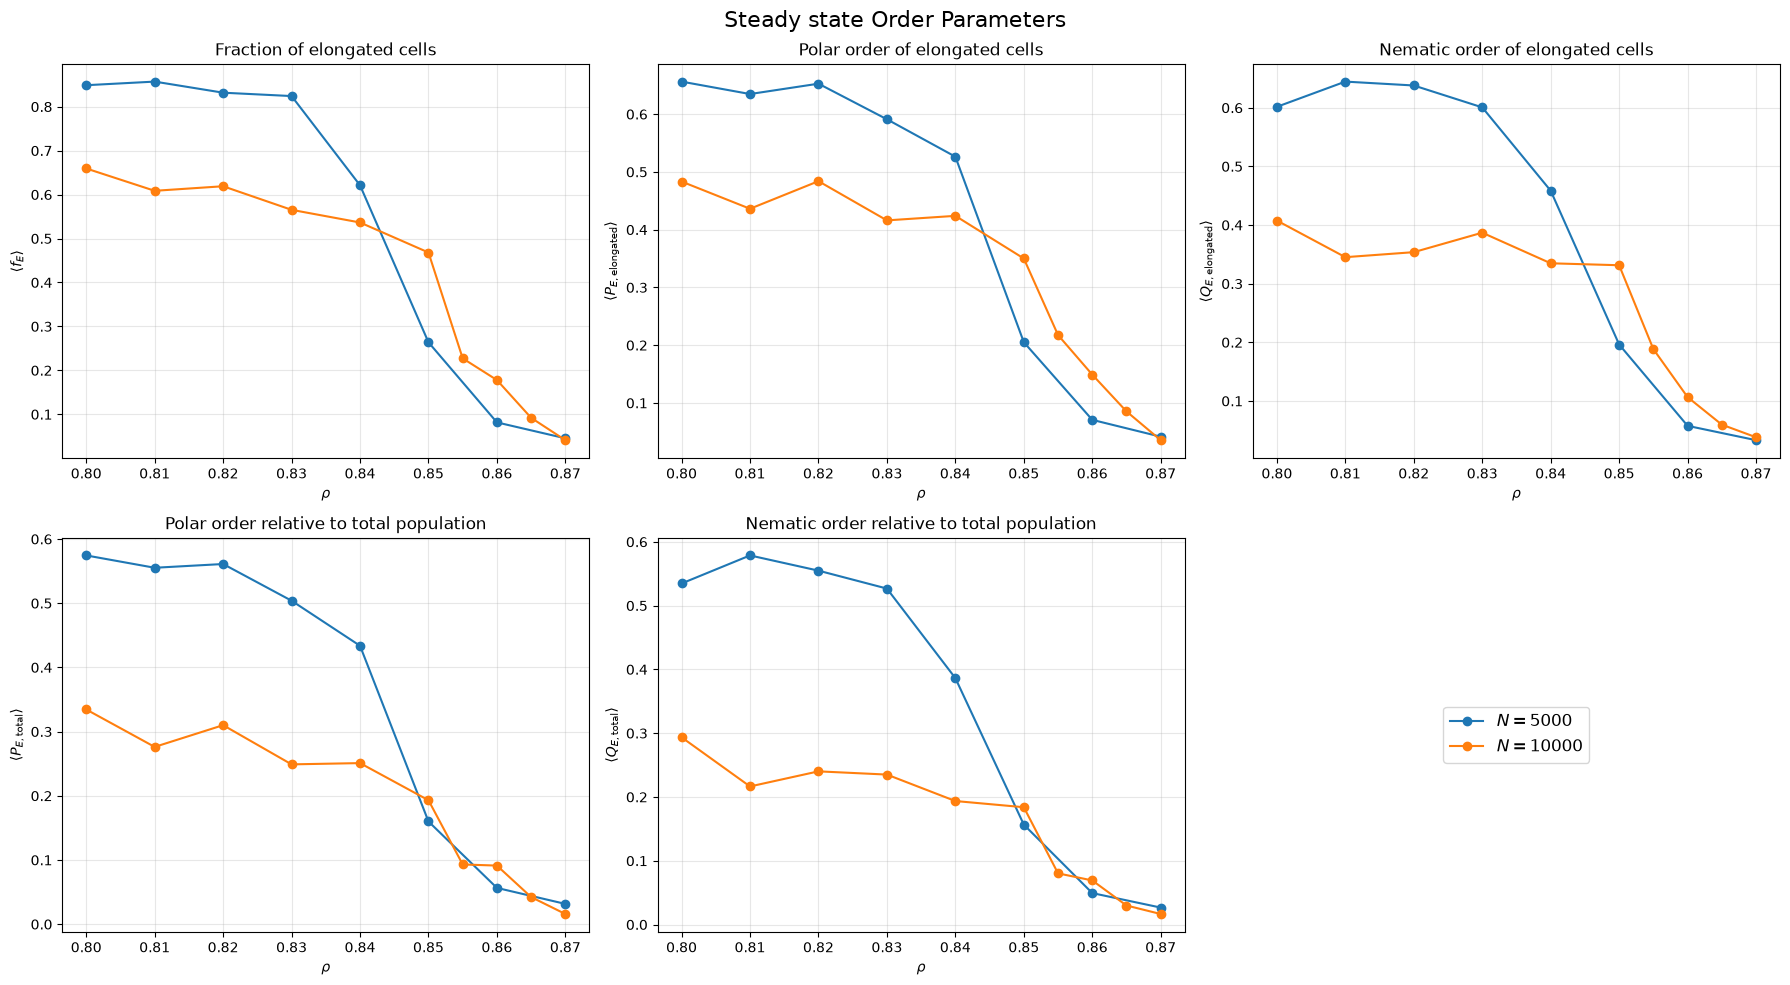

In [17]:
# Plot the order parameters in the steady state for different densities
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Define the observables to plot, along with their labels and titles
observables = [
    (
        "f_E_mean",
        r"$\langle f_E \rangle$",
        "Fraction of elongated cells",
    ),
    (
        "P_E_elongated_mean",
        r"$\langle P_{E,\mathrm{elongated}} \rangle$",
        "Polar order of elongated cells",
    ),
    (
        "Q_E_elongated_mean",
        r"$\langle Q_{E,\mathrm{elongated}} \rangle$",
        "Nematic order of elongated cells",
    ),
    (
        "P_E_total_mean",
        r"$\langle P_{E,\mathrm{total}} \rangle$",
        "Polar order relative to total population",
    ),
    (
        "Q_E_total_mean",
        r"$\langle Q_{E,\mathrm{total}} \rangle$",
        "Nematic order relative to total population",
    ),
]

axs = axs.flatten()

# For each observable, plot one curve for each system size
for ax, (column, ylabel, title) in zip(axs, observables):

    for N, df_N in op_rho_stats.groupby("N"):

        df_N = df_N.sort_values("rho")

        ax.plot(
            df_N["rho"],
            df_N[column],
            marker="o",
            label=fr"$N={N}$",
        )

    ax.set_title(title)
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axs[-1].axis("off")

# Use the empty panel for the legend
handles, labels = axs[0].get_legend_handles_labels()

axs[-1].legend(
    handles,
    labels,
    loc="center",
    fontsize=12,
)

# Plot configuration
graph_title = "Steady state Order Parameters"

fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The late-time $f_E$ remains relatively large at lower densities and decreases sharply between $\rho=0.85$ and $\rho=0.86$. A similar decrease is observed for $P_{E, total}$ and $Q_{E, total}$.

Among the quantities considered here, $f_E$ provides the most direct measure of the morphological state of the system and will therefore be used as the primary observable to characterize the transition.

## Susceptibility

To quantify the fluctuations of the elongated fraction, we define its susceptibility as

\begin{equation}
    \chi_{f_E}=N_{actual}​[⟨f_E^{2}​⟩−⟨f_E​⟩^{2}]
\end{equation}

The temporal moments are first evaluated within the late-time window for each realization and are subsequently averaged over seeds.

In [18]:
# Calculate the first and second moments of f_E
op_steady["f_E_squared"] = op_steady["f_E"]**2

# First average over time for each seed
f_E_moments_seed = (
    op_steady
    .groupby(["N", "rho", "seed"])
    .agg(
        actual_N=("actual_N", "first"),
        f_E_mean=("f_E", "mean"),
        f_E_squared_mean=("f_E_squared", "mean"),
    )
    .reset_index()
)

f_E_moments_seed.head()

,N,rho,seed,actual_N,f_E_mean,f_E_squared_mean
0,5000,0.8,7713914261614,4437,0.998078,0.996160
1,5000,0.8,12944511869278,4437,0.808111,0.653773
2,5000,0.8,37852570490343,4437,0.987595,0.975364
3,5000,0.8,78804909138230,4437,0.997192,0.994393
4,5000,0.8,121838283310165,4437,0.626672,0.393649


In [19]:
# Check the range of actual_N values for each combination of N and rho
actual_N_check = (
    f_E_moments_seed
    .groupby(["N", "rho"])["actual_N"]
    .agg(["min", "max", "nunique"])
)

display(actual_N_check)

min   max  nunique
N     rho                       
5000  0.800  4437  4437        1
      0.810  4492  4492        1
      0.820  4548  4548        1
      0.830  4603  4603        1
      0.840  4659  4659        1
      0.850  4714  4714        1
      0.860  4770  4770        1
      0.870  4825  4825        1
10000 0.800  9000  9000        1
      0.810  9113  9113        1
      0.820  9225  9225        1
      0.830  9338  9338        1
      0.840  9450  9450        1
      0.850  9563  9563        1
      0.855  9619  9619        1
      0.860  9675  9675        1
      0.865  9732  9732        1
      0.870  9788  9788        1

In [20]:
# Then average over seeds
f_E_moments = (
    f_E_moments_seed
    .groupby(["N", "rho"])
    .agg(
        actual_N=("actual_N", "first"),
        f_E_mean=("f_E_mean", "mean"),
        f_E_squared_mean=("f_E_squared_mean", "mean"),
        number_of_seeds=("seed", "nunique"),
    )
    .reset_index()
)

# Calculate susceptibility
f_E_moments["chi_f_E"] = (
    f_E_moments["actual_N"]
    * (
        f_E_moments["f_E_squared_mean"]
        - f_E_moments["f_E_mean"]**2
    )
)

f_E_moments

,N,rho,actual_N,f_E_mean,f_E_squared_mean,number_of_seeds,chi_f_E
0,5000,0.800,4437,0.848888,0.739840,64,85.316413
1,5000,0.810,4492,0.857097,0.756445,64,98.058372
2,5000,0.820,4548,0.831855,0.714660,64,103.137845
3,5000,0.830,4603,0.824188,0.703871,64,113.168787
4,5000,0.840,4659,0.621098,0.513881,64,596.904200
5,5000,0.850,4714,0.263830,0.208816,64,656.234702
6,5000,0.860,4770,0.081588,0.066161,64,283.833575
7,5000,0.870,4825,0.045360,0.034848,64,158.216086
8,10000,0.800,9000,0.659389,0.460208,32,228.732234
9,10000,0.810,9113,0.608586,0.383937,32,123.575348


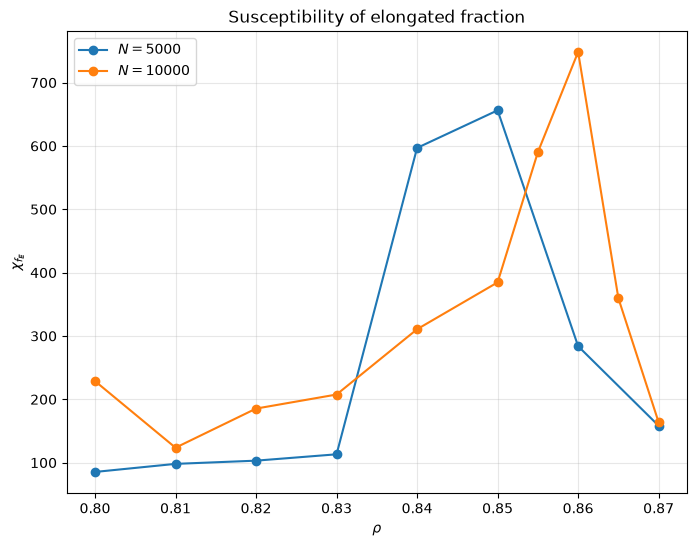

In [21]:
# Plot the susceptibility of the elongated fraction as a function of density
plt.figure(figsize=(8, 6))

for N, df_N in f_E_moments.groupby("N"):

    df_N = df_N.sort_values("rho")

    plt.plot(
        df_N["rho"],
        df_N["chi_f_E"],
        marker="o",
        label=fr"$N={N}$",
    )

plt.xlabel(r"$\rho$")
plt.ylabel(r"$\chi_{f_E}$")

plt.legend()
plt.grid(alpha=0.3)

graph_title = "Susceptibility of elongated fraction"

plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

For $N=10000$, the susceptibility displays a pronounced maximum at $\rho=0.86$, coinciding with the region where the late-time elongated fraction decreases sharply. We therefore use the susceptibility maximum as a reference point to inspect the fluctuations and the distribution of $f_E$ near the transition.

We can also get the density associated to the susceptibility peak and the value of the susceptibility.

In [22]:
# Find the susceptibility peak for each system size
peak_indices = (
    f_E_moments
    .groupby("N")["chi_f_E"]
    .idxmax()
)

susceptibility_peaks = (
    f_E_moments
    .loc[
        peak_indices,
        [
            "N",
            "actual_N",
            "rho",
            "chi_f_E",
            "number_of_seeds",
        ],
    ]
    .rename(
        columns={
            "rho": "rho_peak",
            "chi_f_E": "chi_peak",
        }
    )
    .sort_values("N")
    .reset_index(drop=True)
)

susceptibility_peaks

,N,actual_N,rho_peak,chi_peak,number_of_seeds
0,5000,4714,0.85,656.234702,64
1,10000,9675,0.86,748.414445,32


## Elongated-fraction distributions near the susceptibility peak

To investigate the origin of the enhanced fluctuations, we examine the distribution of the late-time averaged elongated fraction, $\langle f_E \rangle _t$, across independent realizations. We consider the density corresponding to the susceptibility maximum together with the immediately neighboring sampled densities.

In [23]:
# Get the sampled densities immediately below, at, and above
# the susceptibility peak for each system size

rho_near_peak_by_N = {}

for _, peak_row in susceptibility_peaks.iterrows():

    N = int(peak_row["N"])
    rho_peak = peak_row["rho_peak"]

    # Densities available for this system size
    rho_values = np.sort(
        op_seed_stats.loc[
            op_seed_stats["N"] == N,
            "rho",
        ].unique()
    )

    # Position of the susceptibility maximum
    peak_position = np.where(
        np.isclose(rho_values, rho_peak)
    )[0][0]

    # Density below, at, and above the peak
    rho_near_peak = rho_values[
        max(0, peak_position - 1):
        min(len(rho_values), peak_position + 2)
    ]

    rho_near_peak_by_N[N] = rho_near_peak

    print(
        f"N = {N}: "
        f"peak = {rho_peak:.3f}, "
        f"densities used = {rho_near_peak}"
    )

N = 5000: peak = 0.850, densities used = [0.84 0.85 0.86]
N = 10000: peak = 0.860, densities used = [0.855 0.86  0.865]


In [24]:
N_distribution = 10_000

rho_peak = (
    susceptibility_peaks
    .loc[
        susceptibility_peaks["N"] == N_distribution,
        "rho_peak",
    ]
    .iloc[0]
)

rho_near_peak = rho_near_peak_by_N[N_distribution]

print(
    f"N = {N_distribution}, "
    f"susceptibility peak = {rho_peak:.3f}"
)

print("Densities used:", rho_near_peak)

N = 10000, susceptibility peak = 0.860
Densities used: [0.855 0.86  0.865]


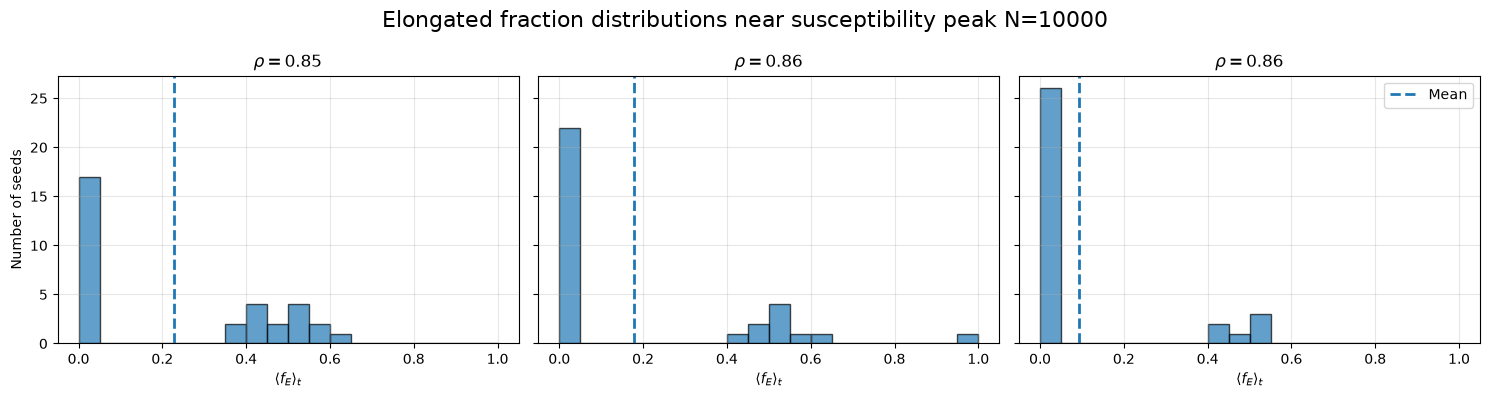

In [25]:
# Plot the distributions of f_E for densities near the susceptibility peak
bins = np.linspace(0, 1, 21)

fig, axs = plt.subplots(
    1,
    len(rho_near_peak),
    figsize=(15, 4),
    sharex=True,
    sharey=True,
)

# For each density near the susceptibility peak,
# plot the histogram of f_E values across seeds
for ax, rho in zip(axs, rho_near_peak):

    data = op_seed_stats[
        (op_seed_stats["N"] == N_distribution)
        & np.isclose(op_seed_stats["rho"], rho)
    ]["f_E"]

    ax.hist(
        data,
        bins=bins,
        edgecolor="black",
        alpha=0.7,
    )

    ax.axvline(
        data.mean(),
        linestyle="--",
        linewidth=2,
        label="Mean",
    )

    ax.set_title(fr"$\rho={rho:.2f}$")
    ax.set_xlabel(r"$\langle f_E\rangle_t$")
    ax.grid(alpha=0.3)

axs[0].set_ylabel("Number of seeds")
axs[-1].legend()

graph_title = (
    f"Elongated fraction distributions near susceptibility peak N={N_distribution}"
)

fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

At $\rho=0.85$, most realizations retain a substantial elongated population, although realizations with very small $f_E$ are already present. At $\rho=0.86$, realizations with $f_E \approx 0$ coexist with others retaining a finite elongated fraction. At $\rho=0.87$, most realizations belong to the low- $f_E$ branch, while a small number remain strongly elongated.

## Individual realizations near the susceptibility peak

To determine whether the broad distribution near the susceptibility maximum originates from distinct dynamical behaviors, we inspect the time evolution of $f_E$ for each independent realization at $\rho=0.86$.

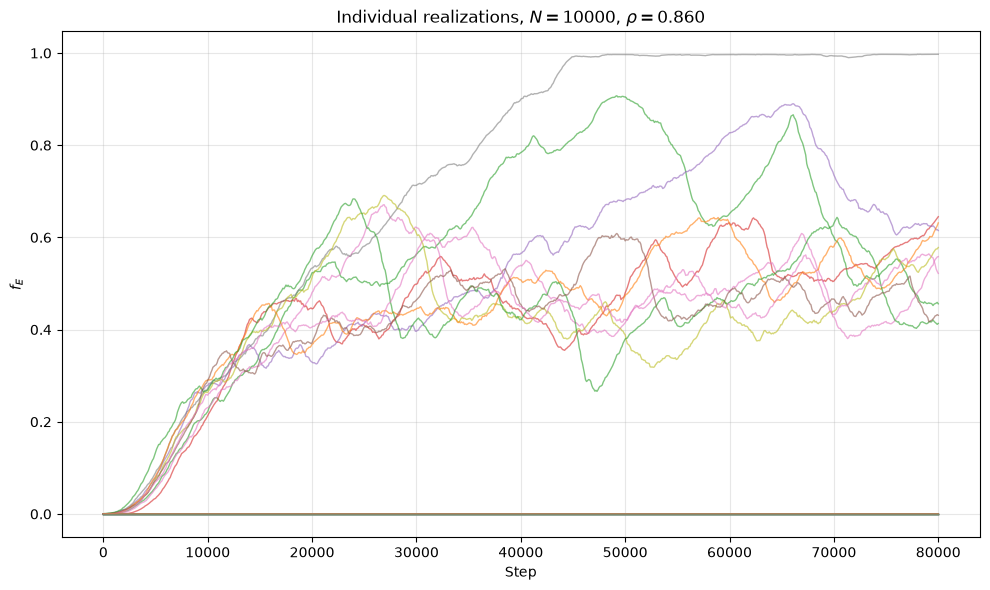

In [26]:
# Plot the time evolution of f_E for individual seeds
# at the susceptibility peak of the largest system

N_individual = N_distribution
rho_selected = rho_peak

df_peak = op[
    (op["N"] == N_individual)
    & np.isclose(op["rho"], rho_selected)
].copy()

plt.figure(figsize=(10, 6))

for seed, df_seed in df_peak.groupby("seed"):

    df_seed = df_seed.sort_values("step")

    plt.plot(
        df_seed["step"],
        df_seed["f_E"],
        alpha=0.6,
        linewidth=1,
    )

plt.xlabel("Step")
plt.ylabel(r"$f_E$")

plt.title(
    fr"Individual realizations, "
    fr"$N={N_individual}$, "
    fr"$\rho={rho_selected:.3f}$"
)

plt.grid(alpha=0.3)

graph_title = (
    f"elongated_fraction_individual_seeds_"
    f"N_{N_individual}_rho_{rho_selected:.3f}"
)

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{graph_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The individual trajectories show a strong separation between realizations. Several remain close to the fully round state, whereas others develop and retain a substantial elongated population.